# Portfolio Analizi - VectorBT ile

Bu notebook, VectorBT kullanarak LOB verilerinden portfolio analizi yapan basit bir projedir.

## Proje Özeti
- **Amaç**: LOB verilerinden portfolio performans analizi yapmak
- **Kütüphane**: VectorBT - Backtesting ve portfolio analizi
- **Veri**: AKBNK hisse senedi LOB verileri
- **Stratejiler**: Momentum, Mean Reversion, Random

## İçerik
1. [Gerekli Kütüphanelerin Yüklenmesi](#1-gerekli-kütüphanelerin-yüklenmesi)
2. [Konfigürasyon Yükleme](#2-konfigürasyon-yükleme)
3. [Portfolio Analyzer Import](#3-portfolio-analyzer-import)
4. [Veri Yükleme](#4-veri-yükleme)
5. [Portfolio Oluşturma](#5-portfolio-oluşturma)
6. [Performans Analizi](#6-performans-analizi)
7. [Görselleştirme](#7-görselleştirme)

## ⚠️ Önemli Not
Bu notebook'u hücreleri sırayla çalıştırın. Her hücre önceki hücrelerin tamamlanmasını bekler.

## 1. Gerekli Kütüphanelerin Yüklenmesi

In [1]:
# Temel kütüphaneler
import os
import sys
import yaml
import warnings
import glob
import pandas as pd
import numpy as np
from pathlib import Path
import json
from datetime import datetime

# VectorBT'i Numba olmadan import et
import os
os.environ['NUMBA_DISABLE_JIT'] = '1'

# Numba'yı devre dışı bırak
import numba
numba.config.DISABLE_JIT = True

# VectorBT import öncesi
import warnings
warnings.filterwarnings('ignore', category=numba.NumbaWarning)

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# VectorBT
import vectorbt as vbt

# Proje kök dizinini bul ve Python path'ine ekle
project_root = os.path.dirname(os.path.abspath('.'))
sys.path.append(project_root)

# Uyarıları kapat
warnings.filterwarnings('ignore')

# VectorBT ayarları
vbt.settings.returns['year_freq'] = '252 days'
vbt.settings.array_wrapper['freq'] = '1T'  # 1 dakika

# Matplotlib ayarları
plt.style.use('seaborn-v0_8')
rcParams['figure.figsize'] = (12, 8)
rcParams['font.size'] = 10

print("✅ Kütüphaneler başarıyla yüklendi!")
print(f"📁 Proje kök dizini: {project_root}")

✅ Kütüphaneler başarıyla yüklendi!
📁 Proje kök dizini: /Users/tolgacoskun-mac/Source/tlob-training


## 2. Konfigürasyon Yükleme

In [2]:
def load_config():
    """Konfigürasyon dosyasını yükle"""
    # Proje kök dizinindeki config dosyasını kullan
    config_path = os.path.join(project_root, 'config', 'config.yaml')
    
    if not os.path.exists(config_path):
        # Alternatif olarak mevcut dizinde ara
        alt_config_path = 'config/config.yaml'
        if os.path.exists(alt_config_path):
            config_path = alt_config_path
        else:
            raise FileNotFoundError(f"Konfigürasyon dosyası bulunamadı: {config_path}")
    
    print(f"📂 Konfigürasyon dosyası yükleniyor: {config_path}")
    with open(config_path, 'r') as file:
        return yaml.safe_load(file)

# Konfigürasyonu yükle
config = load_config()
portfolio_config = config.get('portfolio', {})
print("📋 Portfolio Konfigürasyonu yüklendi:")
print(f"   Strategy Type: {portfolio_config.get('strategy_type', 'random')}")
print(f"   Initial Cash: {portfolio_config.get('init_cash', 10000)}")
print(f"   Data Directory: {portfolio_config.get('data_directory', 'data')}")

# Gerekli dizinleri oluştur
results_dir = os.path.join(project_root, 'results')
os.makedirs(results_dir, exist_ok=True)
print("✅ Gerekli dizinler oluşturuldu")

📂 Konfigürasyon dosyası yükleniyor: /Users/tolgacoskun-mac/Source/tlob-training/config/config.yaml
📋 Portfolio Konfigürasyonu yüklendi:
   Strategy Type: mean_reversion
   Initial Cash: 10000
   Data Directory: data
✅ Gerekli dizinler oluşturuldu


## 3. Portfolio Analyzer Import

In [3]:
# Portfolio analyzer'ı import et
from src.portfolio_analyzer import PortfolioAnalyzer

print("✅ Portfolio analyzer hazır!")

✅ Portfolio analyzer hazır!


## 4. Veri Yükleme

In [4]:
# Portfolio analyzer'ı başlat
print("🏗️ Portfolio analyzer başlatılıyor...")
analyzer = PortfolioAnalyzer(portfolio_config)

🏗️ Portfolio analyzer başlatılıyor...


## 5. Portfolio Oluşturma

In [5]:
# Portfolio oluştur
strategy_type = portfolio_config.get('strategy_type', 'random')
init_cash = portfolio_config.get('init_cash', 10000)

 # Create portfolio from TLOB test data (analyzer will get it internally)
print("\n🏗️ Creating portfolio from TLOB test data...")
portfolio_data = analyzer.create_portfolio_from_test_data()

if portfolio_data is None:
    print("❌ Failed to create portfolio data!")

print(f"   Test Data Shape: {portfolio_data.shape}")

# Create portfolio using from_orders method
print("\n🏗️ Creating portfolio strategy...")
portfolio = analyzer.create_portfolio_from_orders(portfolio_data, strategy_type, init_cash)
    


🏗️ Creating portfolio from TLOB test data...
📊 Creating portfolio from TLOB test data (last 50.0%)...
📊 Creating synthetic test data for testing...
✅ Created synthetic test data: (100, 64, 47)
   Full test data shape: (100, 64, 47)
   Using last 50.0% of data: 50 samples (from index 50)
   Selected data shape: (50, 64, 47)
   Created realistic price series: (50,)
   Price range: 99.98 - 109.93
✅ Portfolio created from test data: 50 time points with symbol: TLOB_TEST
   Test Data Shape: (50, 1)

🏗️ Creating portfolio strategy...
🏗️ Creating portfolio with mean_reversion strategy using VectorBT...
📊 Creating VectorBT portfolio with from_orders...
   📊 Position sizing: 54.86 shares per trade
   💰 Position value: $5500.00 per trade
✅ VectorBT portfolio created successfully with from_orders and trading costs
   📊 Data stored - Price: (50, 1)
   📊 Data stored - Decisions: (50, 1)


## 6. Performans Analizi

In [6]:
# Portfolio performansını analiz et
print("📊 Portfolio performansı analiz ediliyor...")
performance = analyzer.analyze_performance()

# Performans raporunu yazdır
analyzer.print_performance_report(performance)

📊 Portfolio performansı analiz ediliyor...
📊 Analyzing portfolio performance...
   ✅ Basic stats obtained: ['Start', 'End', 'Period', 'Start Value', 'End Value', 'Total Return [%]', 'Benchmark Return [%]', 'Max Gross Exposure [%]', 'Total Fees Paid', 'Max Drawdown [%]', 'Max Drawdown Duration', 'Total Trades', 'Total Closed Trades', 'Total Open Trades', 'Open Trade PnL', 'Win Rate [%]', 'Best Trade [%]', 'Worst Trade [%]', 'Avg Winning Trade [%]', 'Avg Losing Trade [%]', 'Avg Winning Trade Duration', 'Avg Losing Trade Duration', 'Profit Factor', 'Expectancy', 'Sharpe Ratio', 'Calmar Ratio', 'Omega Ratio', 'Sortino Ratio']
   ✅ Returns obtained, shape: (50, 1)
   ✅ Clean returns, length: 50
   ✅ Sharpe ratio calculated: 0.0612
   ✅ Performance analysis completed successfully

📊 PORTFÖY PERFORMANS RAPORU (VectorBT)
💰 Toplam Getiri:           1.69%
📈 Yıllık Getiri:           1.69%
📊 Yıllık Volatilite:       0.00%
⚖️  Sharpe Oranı:            0.061
📉 Maksimum Drawdown:        2.79%

📊 TRAD

## 7. Görselleştirme

📊 Portfolio görselleştirmesi oluşturuluyor...
📊 Creating portfolio plots...
      ✅ Price plot successful
      ✅ Buy signals plotted: 21
      ✅ Sell signals plotted: 9
      ✅ Hold signals plotted: 20
      ✅ Plot 4 completed successfully


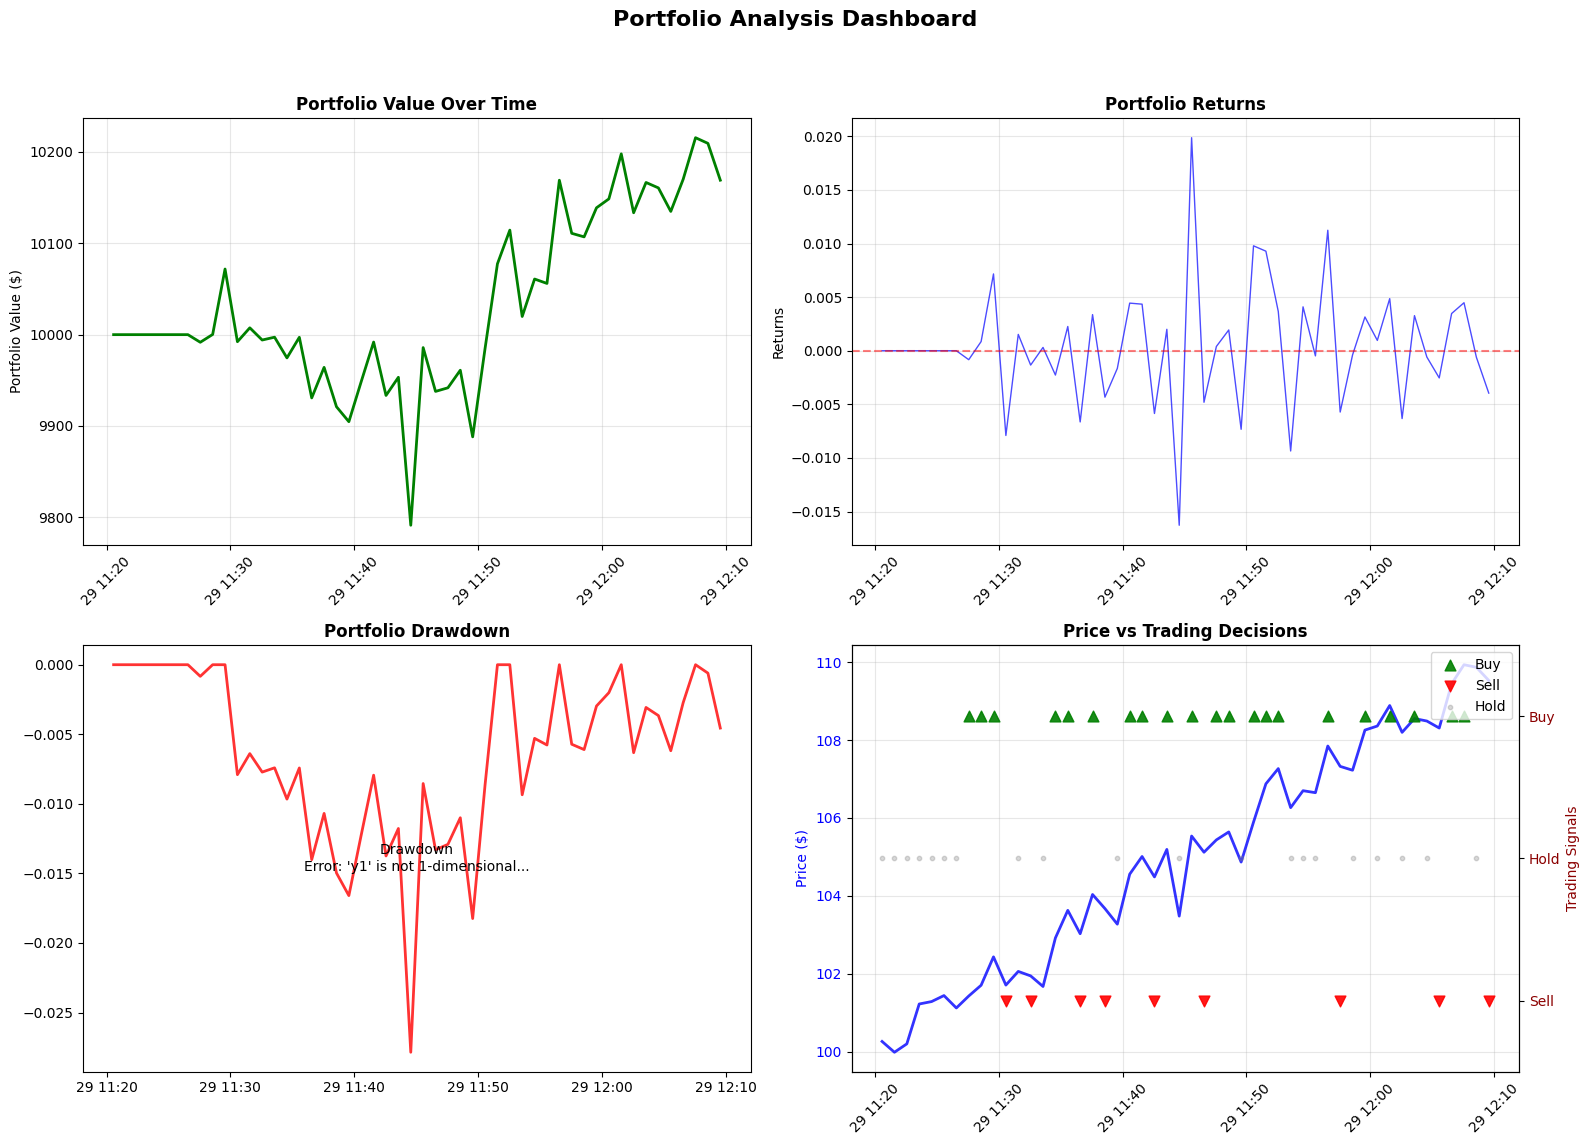

✅ Portfolio görselleştirmesi tamamlandı!


In [7]:
# Portfolio görselleştirmesi
print("📊 Portfolio görselleştirmesi oluşturuluyor...")
analyzer.plot_portfolio()

print("✅ Portfolio görselleştirmesi tamamlandı!")

## 9. Sonuçları Kaydetme

In [8]:
# Sonuçları kaydet
print("💾 Portfolio sonuçları kaydediliyor...")

# Ana portfolio sonuçları
portfolio_results = {
    'strategy': strategy_type,
    'initial_cash': init_cash,
    'performance': performance,
    'timestamp': datetime.now().isoformat()
}

# JSON dosyalarına kaydet
portfolio_file = os.path.join(results_dir, 'portfolio_analysis.json')
comparison_file = os.path.join(results_dir, 'portfolio_comparison.json')

with open(portfolio_file, 'w', encoding='utf-8') as f:
    json.dump(portfolio_results, f, indent=2, ensure_ascii=False, default=str)

print("✅ Portfolio sonuçları kaydedildi:")
print(f"   Portfolio analizi: {portfolio_file}")
print(f"   Strateji karşılaştırması: {comparison_file}")

print("\n🎉 Portfolio Analizi Tamamlandı!")

💾 Portfolio sonuçları kaydediliyor...
✅ Portfolio sonuçları kaydedildi:
   Portfolio analizi: /Users/tolgacoskun-mac/Source/tlob-training/results/portfolio_analysis.json
   Strateji karşılaştırması: /Users/tolgacoskun-mac/Source/tlob-training/results/portfolio_comparison.json

🎉 Portfolio Analizi Tamamlandı!
